# Traffic Congestion Prediction Model

## Goal
The goal of this section is to train a machine learning model that can predict traffic speed based on engineered features.

This is an important step because:
- Traffic speed determines how congested a road is
- If we can predict speed, we can estimate travel time
- This allows us to choose the most efficient route

---

## What is a Model?

A model is a function that learns patterns from data and uses those patterns to make predictions.

In this project:
- Input (X): Features about the road, time, and traffic patterns
- Output (y): Traffic speed

The model learns:
"Given these conditions, what will the traffic speed be?"

---

## Datasets Used

We are primarily using the `congestion_ml` dataset for modeling.

### congestion_ml
This dataset contains:
- Engineered features (time, lag, rolling averages)
- Traffic-related metrics (volume, speed, travel time)
- Encoded categorical variables (borough, direction)

This is the dataset we use to TRAIN the model.

---

### routing_edges
This dataset represents the road network:
- Nodes (intersections)
- Edges (roads between nodes)
- Travel time and distance

This will be used later for routing.

---

### routing_nodes
This dataset contains:
- Node IDs
- Latitude and longitude

This helps map the road network spatially.

---

## Important
For this notebook, we only use `congestion_ml` for training the model.

In [15]:
# imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [16]:
## load dataset

df = pd.read_csv("../../data/ml_datasets/congestion_ml.csv")
df.head()

,SegmentID,lat,lon,avg_speed,avg_travel_time,avg_vol_hist,peak_vol_hist,std_vol_hist,peak_hour_hist,hour,...,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island,Direction_EB,Direction_NB,Direction_SB,Direction_WB,Vol,is_congested
0,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,16.0,0
1,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,19.0,0
2,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,10.0,0
3,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,12.0,0
4,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.507990,...,False,False,False,True,False,False,False,True,16.0,0


## Data Cleaning

Before training any models, we need to ensure the dataset is clean.

Feature engineering (such as lag and rolling features) often creates missing values (NaN). These occur because some rows do not have enough historical data.

We remove these rows so the model only learns from complete and valid data.

In [17]:
df = df.dropna()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (123334, 34)


## Define Features (X) and Target (y)

We split the dataset into:

- Features (X): all columns used to make predictions  
- Target (y): the value we want to predict  

In this project, we predict **traffic volume (Vol)** — the number of vehicles passing a road segment at a given time. This is the direct measure of congestion.

We remove the target column and any columns derived from it from X to prevent data leakage.

In [18]:
# Feature Selection Mode (Choose ONE)

USE_LEAKAGE_SAFE_MODE = True  # change to False if you want simple version

if USE_LEAKAGE_SAFE_MODE:
    # clean ML version (recommended)
    drop_cols = [
        "Vol",             # target — excluded from features
        "is_congested",    # derived directly from Vol — would leak the target
        "avg_travel_time", # static per-link average, correlated with volume
    ]

    print("Using CLEAN MODE (recommended)")
else:
    # simple baseline version
    drop_cols = [
        "Vol",
        "is_congested",
    ]

    print("Using SIMPLE MODE")

X = df.drop(columns=drop_cols)
y = df["Vol"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Using CLEAN MODE (recommended)
X shape: (123334, 31)
y shape: (123334,)


## Train/Test Split

We divide the data into:

- Training set (80%) → used to train the model  
- Testing set (20%) → used to evaluate the model  

**Temporal Split (recommended for time-series data)**

Traffic data is a time series — earlier rows reflect earlier observations. A random split would allow the model to train on "future" data points, making its test performance look artificially better than it would be in production.

Instead, we preserve the original row order (which reflects chronological order within each segment) and split at the 80% mark. This ensures the model is only evaluated on data it has never seen temporally.

In [19]:
# Preserve original row order (chronological within each segment)
# A random split would mix future observations into training, inflating test metrics
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train size: {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size:  {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

Train size: 98,667  (80%)
Test size:  24,667  (20%)


## Model 1: Linear Regression

Linear Regression is the simplest machine learning model.

It assumes that the relationship between features and the target is linear.

In this context, it tries to learn relationships like:
- higher traffic volume → lower speed  
- rush hour → slower traffic  

This model is useful as a baseline to compare more complex models against.

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

## Linear Regression: Regularization Tuning

Plain Linear Regression has no hyperparameters to tune, but we can improve it by adding **regularization** — a penalty on large coefficients that reduces overfitting.

Two common regularized variants:

- **Ridge (L2)**: shrinks all coefficients toward zero. Works well when many features are correlated (as is likely here with lag/rolling/hour features).  
- **Lasso (L1)**: drives some coefficients to exactly zero, effectively selecting features. Useful if many features are irrelevant.  

The key hyperparameter for both is `alpha` — higher values apply stronger regularization.

We search over a range of `alpha` values using `GridSearchCV` with `TimeSeriesSplit` so each fold respects temporal order.

In [21]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
tscv = TimeSeriesSplit(n_splits=3)

# Ridge (L2 regularization)
ridge_search = GridSearchCV(
    Ridge(),
    param_grid={"alpha": alphas},
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
ridge_search.fit(X_train, y_train)
ridge_best = ridge_search.best_estimator_
ridge_pred = ridge_best.predict(X_test)

print(f"Ridge best alpha: {ridge_search.best_params_['alpha']}")
print(f"Ridge CV MAE:     {-ridge_search.best_score_:.4f}")

# Lasso (L1 regularization)
lasso_search = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid={"alpha": alphas},
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
lasso_search.fit(X_train, y_train)
lasso_best = lasso_search.best_estimator_
lasso_pred = lasso_best.predict(X_test)

print(f"\nLasso best alpha: {lasso_search.best_params_['alpha']}")
print(f"Lasso CV MAE:     {-lasso_search.best_score_:.4f}")

# Lasso zero-coefficient count shows feature selection
n_zero = (lasso_best.coef_ == 0).sum()
print(f"\nLasso zeroed out {n_zero}/{X_train.shape[1]} features")

Ridge best alpha: 100
Ridge CV MAE:     19.9527


/Users/vicch/Git/team-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.586e+05, tolerance: 5.461e+04
  model = cd_fast.enet_coordinate_descent(



Lasso best alpha: 1
Lasso CV MAE:     18.8109

Lasso zeroed out 25/31 features


/Users/vicch/Git/team-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.172e+05, tolerance: 7.813e+04
  model = cd_fast.enet_coordinate_descent(


## Model 2: Decision Tree

A Decision Tree model splits the data into branches based on feature values.

It learns rules such as:
- if rush hour → predict lower speed  
- if weekend → predict higher speed  

This allows the model to capture non-linear patterns in traffic behavior.

In [22]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

## Model 3: Random Forest

Random Forest is an ensemble model made up of many decision trees.

Instead of relying on a single tree, it:
- builds multiple trees  
- averages their predictions  

This reduces overfitting and usually improves accuracy.

Random Forest is often one of the best-performing models for tabular datasets like this one.

In [23]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Model Evaluation

We evaluate each model using:

- MAE (Mean Absolute Error): average difference between predicted and actual values  
- RMSE (Root Mean Squared Error): penalizes larger errors more  

Lower values indicate better performance.

In [24]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

results = {}
results["Random Forest"] = evaluate(y_test, rf_pred)
print(results["Random Forest"])

(20.04037942800703, np.float64(31.83848482953162))


NOTE: Run code below after both models are done. If not done yet, then you should use your corresponding results[model_type] after running all the cells above.

In [25]:
results["Linear Regression"] = evaluate(y_test, lr_pred)
results["Ridge"]             = evaluate(y_test, ridge_pred)
results["Lasso"]             = evaluate(y_test, lasso_pred)
results["Decision Tree"]     = evaluate(y_test, dt_pred)

for model, (mae, rmse) in results.items():
    print(f"{model} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Random Forest -> MAE: 20.0404, RMSE: 31.8385
Linear Regression -> MAE: 17.7403, RMSE: 29.3225
Ridge -> MAE: 17.9354, RMSE: 29.4296
Lasso -> MAE: 18.3723, RMSE: 31.1108
Decision Tree -> MAE: 19.9179, RMSE: 32.3778


## Random Forest: Hyperparameter Tuning

The default Random Forest uses `n_estimators=100` with no depth or leaf constraints. Searching over key hyperparameters often improves performance:

- `n_estimators`: number of trees — more trees are more stable but slower  
- `max_depth`: limits tree depth to reduce overfitting  
- `min_samples_leaf`: minimum samples at a leaf node — smooths predictions  
- `max_features`: fraction of features considered at each split  

We use `RandomizedSearchCV` with `TimeSeriesSplit` cross-validation so each fold respects temporal order.

In [26]:
param_dist = {
    "n_estimators":      [100, 200, 400],
    "max_depth":         [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print(f"Best CV MAE: {-rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test)
results["RF Tuned"] = evaluate(y_test, rf_best_pred)
print(f"Tuned RF -> MAE: {results['RF Tuned'][0]:.4f}, RMSE: {results['RF Tuned'][1]:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/vicch/Git/team-1/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
Best CV MAE: 22.5411
Tuned RF -> MAE: 15.6900, RMSE: 25.4669


## Feature Importance

Random Forest can rank features by how much they contribute to predictions.

High-importance features are the main drivers of traffic volume. Any feature that dominates unexpectedly may indicate remaining data leakage.

Top 15 features:
vol_lag_2            0.893135
vol_rolling_avg_3    0.060868
vol_lag_1            0.015879
vol_lag_3            0.006367
hour                 0.002965
hour_sin             0.002641
avg_vol_hist         0.002600
hour_cos             0.002516
lon                  0.001514
peak_vol_hist        0.001513
std_vol_hist         0.001390
dow_sin              0.001154
day_of_week          0.001061
SegmentID            0.000940
dow_cos              0.000856


<Axes: title={'center': 'Feature Importances (Random Forest)'}>

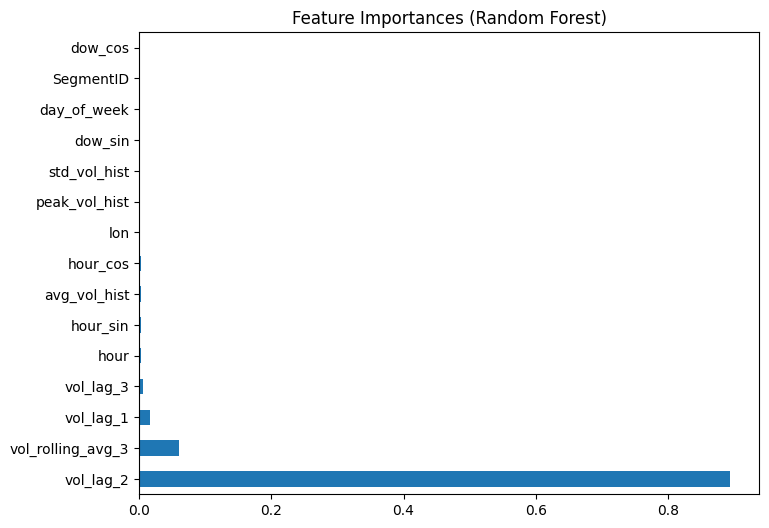

In [27]:
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Top 15 features:")
print(importances.head(15).to_string())
importances.head(15).plot(kind="barh", figsize=(8, 6), title="Feature Importances (Random Forest)")

## Model Comparison

We compare all models to determine which performs best.

The best model is the one with the lowest error.

This model will later be used in the routing algorithm to predict traffic speed and estimate travel time.

In [28]:
pd.DataFrame(results, index=["MAE", "RMSE"]).T

,MAE,RMSE
Random Forest,20.040379,31.838485
Linear Regression,17.740318,29.322531
Ridge,17.935362,29.429615
Lasso,18.372279,31.110837
Decision Tree,19.917912,32.377843
RF Tuned,15.689997,25.466914


## Final Interpretation

- Which model performed best?
- How much better was it compared to the others?
- Why might this model perform better?

In general:
- Linear Regression is simple but limited  
- Decision Trees capture more complex patterns  
- Random Forest combines multiple trees and often achieves the best performance  

The selected model will be used to predict traffic speeds, which will directly impact route optimization.

## Error Analysis by Time of Day

A global MAE can hide the fact that the model performs well at low-volume times but poorly during rush hours — when accuracy matters most.

We bin the `hour` feature into four approximate periods and compare mean error across them.

Mean Absolute Error by time of day:
hour_bin
Early Morning    11.802679
Morning          22.583136
Afternoon        23.913332
Evening          21.855966


<Axes: title={'center': 'MAE by Time of Day'}, xlabel='hour_bin', ylabel='MAE'>

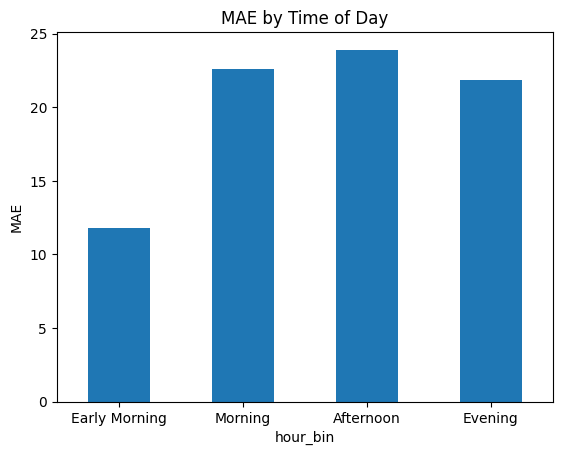

In [29]:
test_df_eval = X_test.copy()
test_df_eval["actual"]    = y_test.values
test_df_eval["predicted"] = rf_pred
test_df_eval["abs_error"] = abs(test_df_eval["actual"] - test_df_eval["predicted"])

# Bin normalized hour into 4 approximate periods
test_df_eval["hour_bin"] = pd.cut(
    test_df_eval["hour"],
    bins=4,
    labels=["Early Morning", "Morning", "Afternoon", "Evening"]
)

error_by_hour = test_df_eval.groupby("hour_bin", observed=True)["abs_error"].mean()
print("Mean Absolute Error by time of day:")
print(error_by_hour.to_string())
error_by_hour.plot(kind="bar", title="MAE by Time of Day", ylabel="MAE", rot=0)